# Nonlinear Cart-Pole control practice

상태는 $x=(p,\theta,\dot p,\dot\theta)\in\mathbb{R}^4$, 제어입력은 $u\in\mathbb{R}$입니다. $M=m_c+m_p$와

$$
a(x,u)=\frac{u+m_p\ell\dot\theta^2\sin\theta}{M}
$$

를 두면

$$
\ddot\theta=
\frac{g\sin\theta-\cos\theta\,a(x,u)}
{\ell\left(\frac43-\frac{m_p\cos^2\theta}{M}\right)},
$$

$$
\ddot p=a(x,u)-\frac{m_p\ell\ddot\theta\cos\theta}{M}.
$$

따라서 $\dot x=f(x,u)$인 4차원 비선형 제어계입니다.

전체 vector field는 4차원이어서 직접 2D quiver로 그릴 수 없으므로, 시각화에서는 $p=\dot p=0$으로 고정한 $(\theta,\dot\theta)$ slice를 사용합니다.


In [1]:
!git clone -q https://github.com/HisameOgasahara/RL_tmp.git
%cd RL_tmp
!pip install -q -r requirements.txt
import sys
sys.path.append("src")


/content/RL_tmp


## 1. 공통 설정

$x_0=(0,0.2,0,0)$에서 시작하고 목표 상태는 $x_{\mathrm{goal}}=(0,0,0,0)$입니다.


In [2]:
import numpy as np
import torch

from rl_tmp.cartpole_system import CartPoleConfig
from rl_tmp.cartpole_solver import (
    make_lqr_controller,
    solve_cartpole_reference,
)
from rl_tmp.cartpole_visualize import (
    plot_cartpole_neural_ode_fields,
    plot_cartpole_pinn_phase_field,
    plot_cartpole_rl_closed_loop_fields,
    plot_cartpole_solver_fields,
    plot_state_trajectories,
    plot_training,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

t_final = 5.0
dt = 0.02

initial_state = np.array(
    [0.0, 0.2, 0.0, 0.0],
    dtype=np.float64,
)

config = CartPoleConfig()
times = np.arange(0.0, t_final + 1e-9, dt)

print("device:", device)
print("time steps:", len(times))
print("initial state:", initial_state)


device: cpu
time steps: 251
initial state: [0.  0.2 0.  0. ]


## 2. DOP853 reference + LQR

DOP853로 비선형 ODE reference를 만들고, $x=0$에서 선형화한 $\dot x=Ax+Bu$에 대해 $u=-Kx$를 구합니다.


LQR gain K:
[[ -2.5819889  -45.8462856   -5.0144165  -12.09511023]]
uncontrolled final state norm: 6.768948823459978
LQR final state norm: 0.019255141785996396


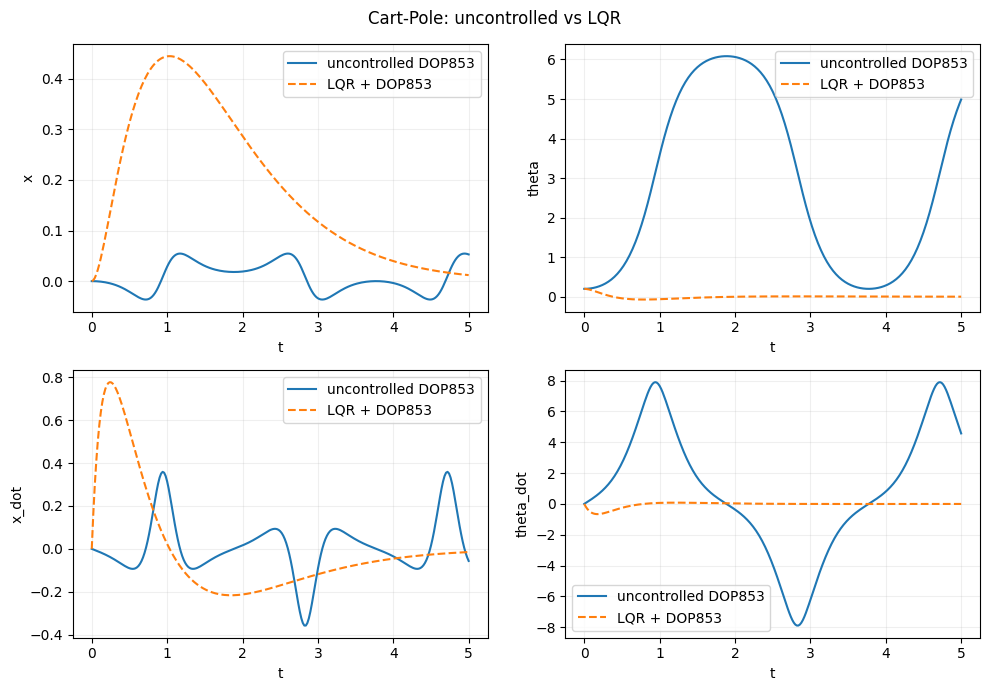

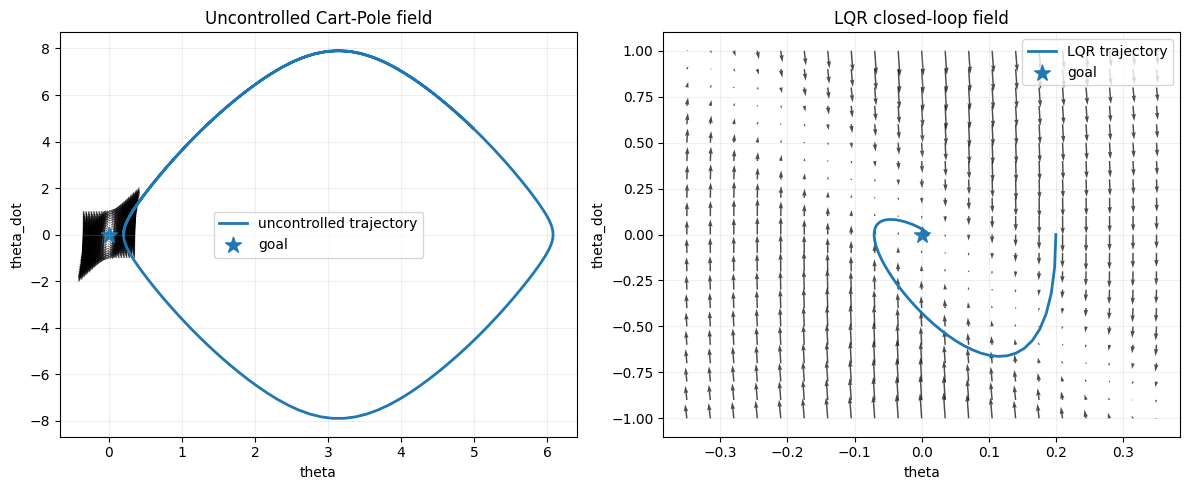

In [3]:
lqr_policy, lqr_gain, A, B = make_lqr_controller(config)

uncontrolled = solve_cartpole_reference(
    initial_state=initial_state,
    times=times,
    config=config,
)

lqr_trajectory = solve_cartpole_reference(
    initial_state=initial_state,
    times=times,
    config=config,
    control_law=lqr_policy,
)

print("LQR gain K:")
print(lqr_gain)
print(
    "uncontrolled final state norm:",
    np.linalg.norm(uncontrolled[-1]),
)
print(
    "LQR final state norm:",
    np.linalg.norm(lqr_trajectory[-1]),
)

plot_state_trajectories(
    times=times,
    reference=uncontrolled,
    prediction=lqr_trajectory,
    labels=("uncontrolled DOP853", "LQR + DOP853"),
    title="Cart-Pole: uncontrolled vs LQR",
)

plot_cartpole_solver_fields(
    config=config,
    uncontrolled=uncontrolled,
    lqr_trajectory=lqr_trajectory,
    lqr_gain=lqr_gain,
)


## 3. PINN

LQR closed-loop ODE

$$
\dot x=f(x,-Kx)
$$

를 만족하는 trajectory $x_\theta:[0,T]\to\mathbb{R}^4$를 학습합니다.


PINN residual: 45.52627944946289 -> 0.032852381467819214
trajectory MSE: 0.003294065902393336
final-state error: 0.10325400049619815


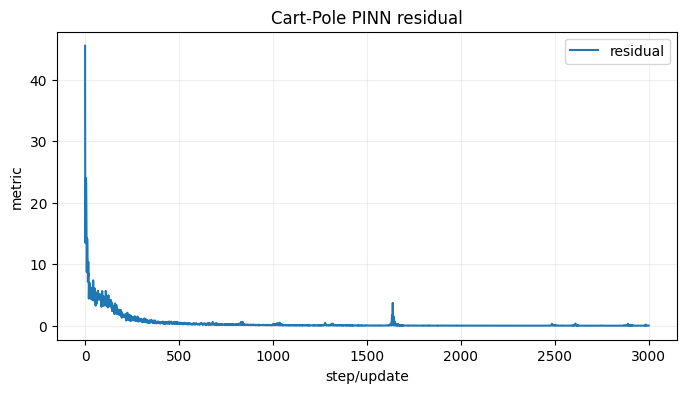

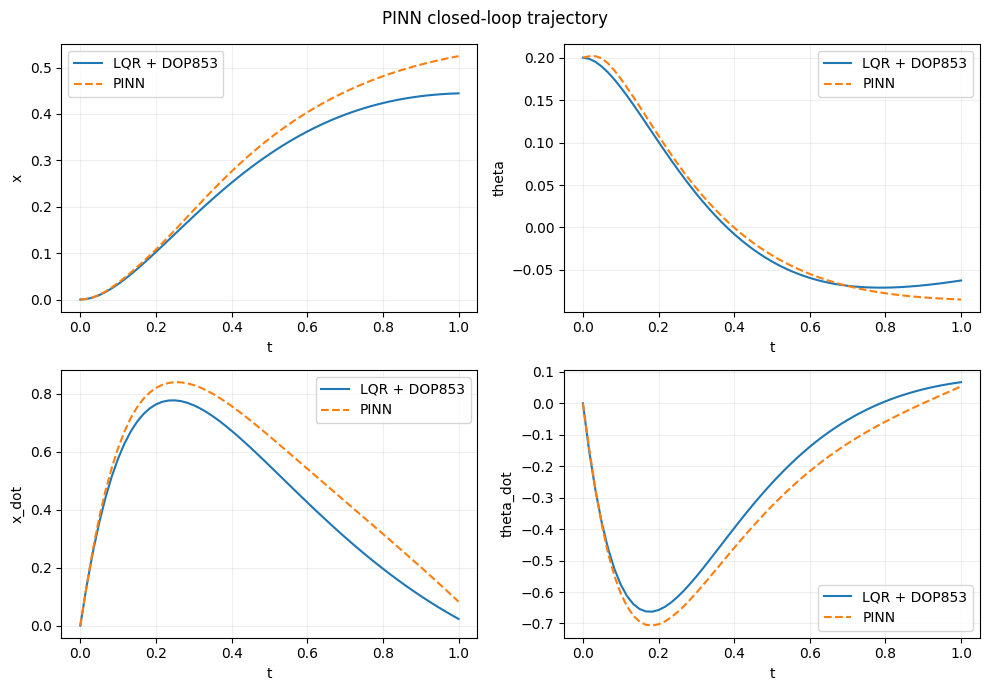

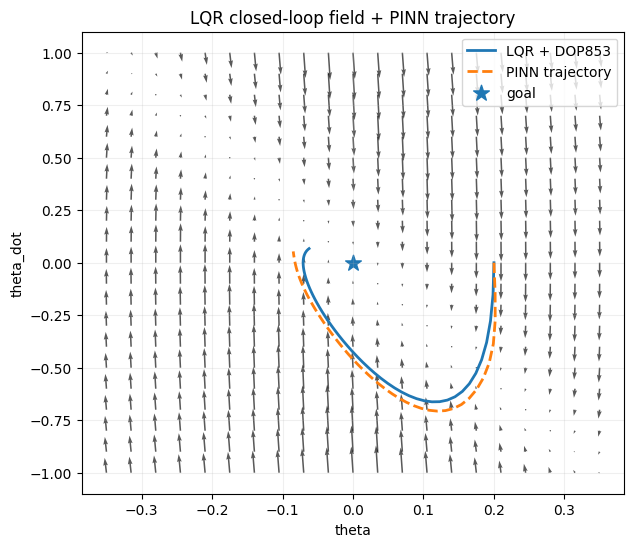

In [4]:
from rl_tmp.cartpole_pinn import (
    predict_cartpole_pinn,
    train_cartpole_pinn,
)

pinn_t_final = 1.0
pinn_times = np.linspace(0.0, pinn_t_final, 61)

pinn_reference = solve_cartpole_reference(
    initial_state=initial_state,
    times=pinn_times,
    config=config,
    control_law=lqr_policy,
)

pinn_result = train_cartpole_pinn(
    initial_state=initial_state,
    config=config,
    lqr_gain=lqr_gain,
    t_final=pinn_t_final,
    steps=3000,
    collocation_points=160,
    seed=0,
    device=device,
)

pinn_prediction = predict_cartpole_pinn(
    model=pinn_result.model,
    times=pinn_times,
    device=device,
).numpy()

pinn_mse = np.mean(
    (pinn_prediction - pinn_reference) ** 2
)

pinn_final_error = np.linalg.norm(
    pinn_prediction[-1] - pinn_reference[-1]
)

print(
    "PINN residual:",
    pinn_result.history["residual"][0],
    "->",
    pinn_result.history["residual"][-1],
)
print("trajectory MSE:", pinn_mse)
print("final-state error:", pinn_final_error)

plot_training(
    pinn_result.history,
    title="Cart-Pole PINN residual",
)

plot_state_trajectories(
    times=pinn_times,
    reference=pinn_reference,
    prediction=pinn_prediction,
    labels=("LQR + DOP853", "PINN"),
    title="PINN closed-loop trajectory",
)

plot_cartpole_pinn_phase_field(
    config=config,
    lqr_gain=lqr_gain,
    reference=pinn_reference,
    pinn_trajectory=pinn_prediction,
)


## 4. Neural ODE

DOP853 trajectory에서 vector field

$$
f_\theta:\mathbb{R}^4\to\mathbb{R}^4
$$

를 학습하고 $\dot x=f_\theta(x)$를 적분합니다.


field MSE: 28.405162811279297 -> 0.006900670472532511
trajectory MSE: 0.005182328519552244
final-state error: 0.22483245862676687


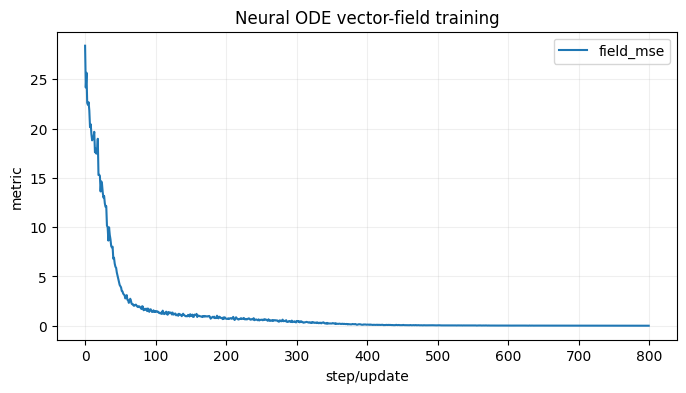

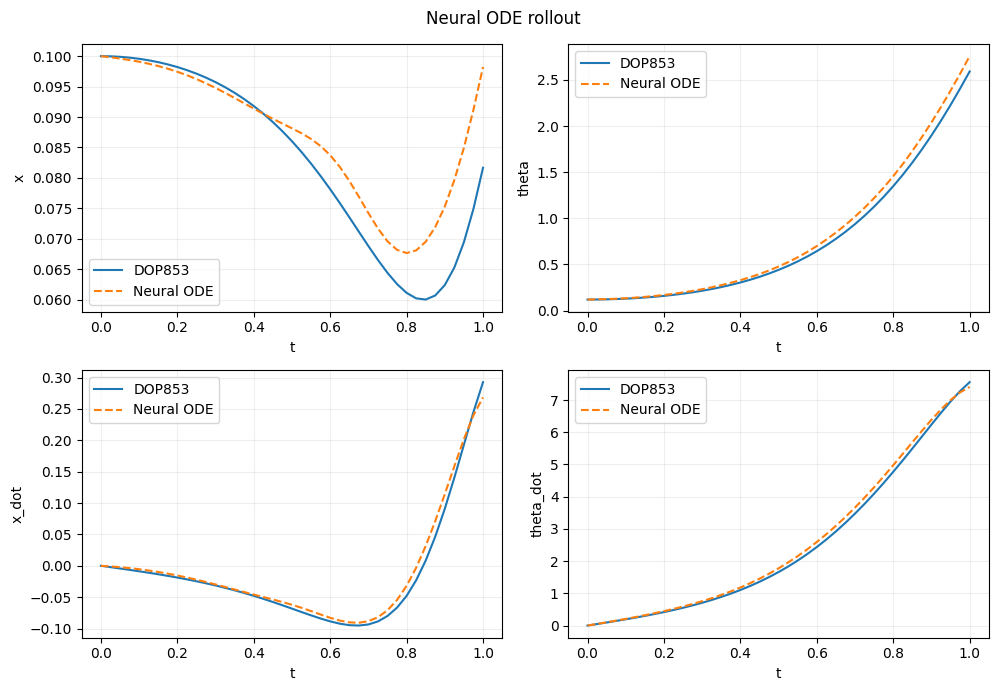

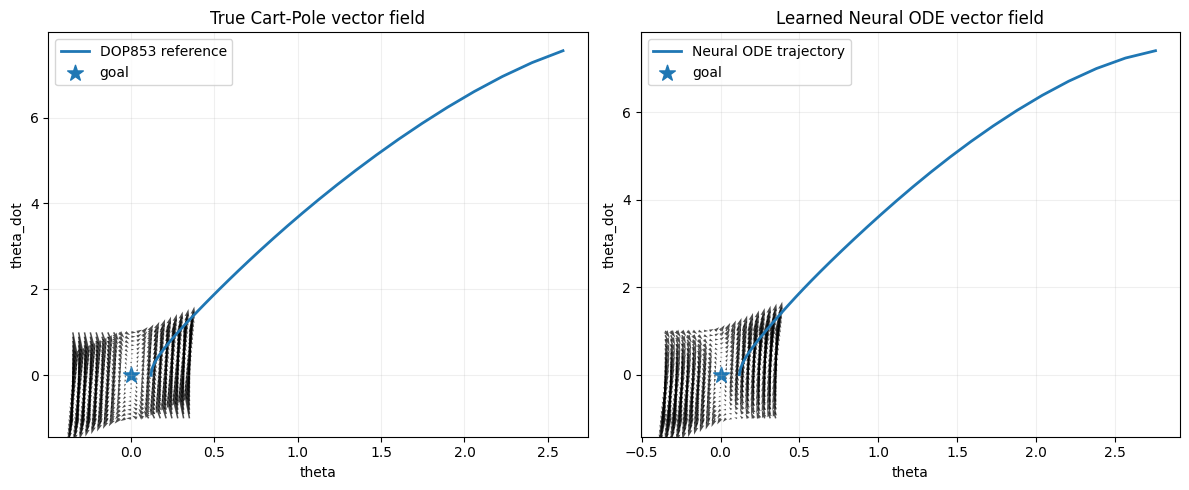

In [5]:
from rl_tmp.cartpole_neural_ode import (
    rollout_learned_field,
    train_cartpole_neural_ode,
)

neural_result = train_cartpole_neural_ode(
    config=config,
    steps=800,
    seed=0,
    device=device,
)

neural_times = np.linspace(0.0, 1.0, 41)
neural_initial_state = np.array(
    [0.1, 0.12, 0.0, 0.0],
    dtype=np.float64,
)

neural_reference = solve_cartpole_reference(
    initial_state=neural_initial_state,
    times=neural_times,
    config=config,
)

neural_prediction = rollout_learned_field(
    model=neural_result.model,
    initial_state=neural_initial_state,
    times=neural_times,
    device=device,
).numpy()

neural_mse = np.mean(
    (neural_prediction - neural_reference) ** 2
)

neural_final_error = np.linalg.norm(
    neural_prediction[-1] - neural_reference[-1]
)

print(
    "field MSE:",
    neural_result.history["field_mse"][0],
    "->",
    neural_result.history["field_mse"][-1],
)
print("trajectory MSE:", neural_mse)
print("final-state error:", neural_final_error)

plot_training(
    neural_result.history,
    title="Neural ODE vector-field training",
)

plot_state_trajectories(
    times=neural_times,
    reference=neural_reference,
    prediction=neural_prediction,
    labels=("DOP853", "Neural ODE"),
    title="Neural ODE rollout",
)

plot_cartpole_neural_ode_fields(
    config=config,
    learned_model=neural_result.model,
    reference=neural_reference,
    learned_trajectory=neural_prediction,
    device=device,
)


## 5. RL control

목표 상태는 $x_{\mathrm{goal}}=(0,0,0,0)$입니다. 정책은

$$
\pi_w(x)=\operatorname{clip}\!\left(-w^\top(x-x_{\mathrm{goal}}),-F_{\max},F_{\max}\right),
\qquad
\pi_w:\mathbb{R}^4\to\mathbb{R}
$$

이고 CEM policy search로 $w\in\mathbb{R}^4$를 학습합니다.


initial state distance to goal: 0.2
elite mean goal distance: 7.617751598358154 -> 0.044972773641347885
final state distance to goal: 0.04487204551696777
reached goal: True
final state: [ 0.04225228  0.00069768 -0.01504087 -0.00123724]


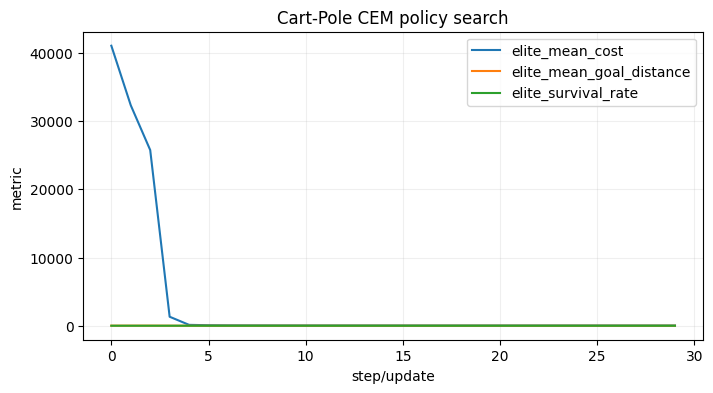

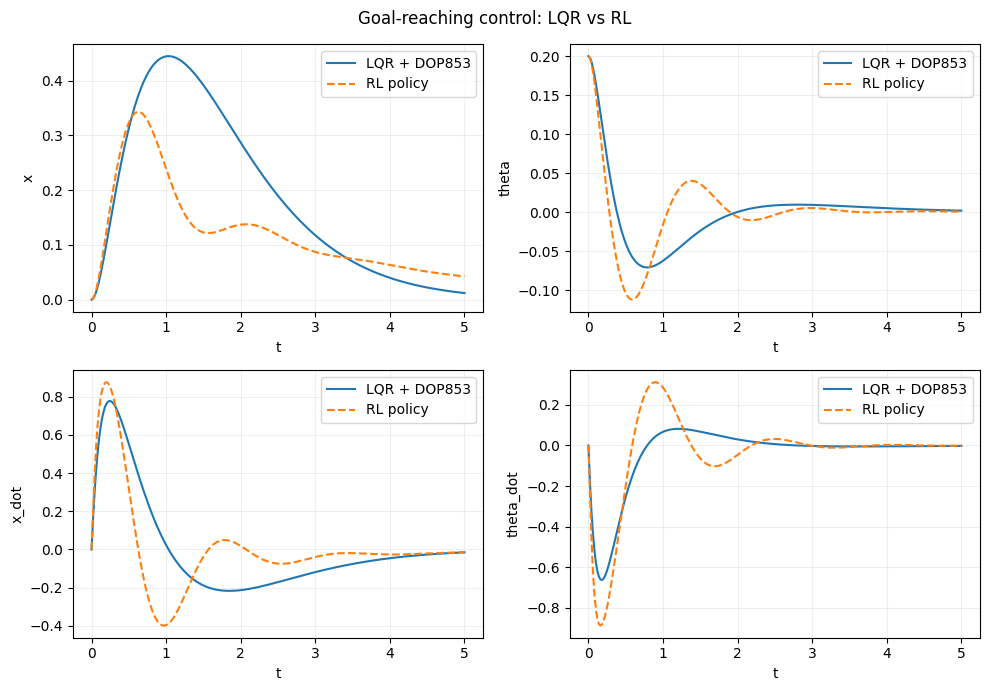

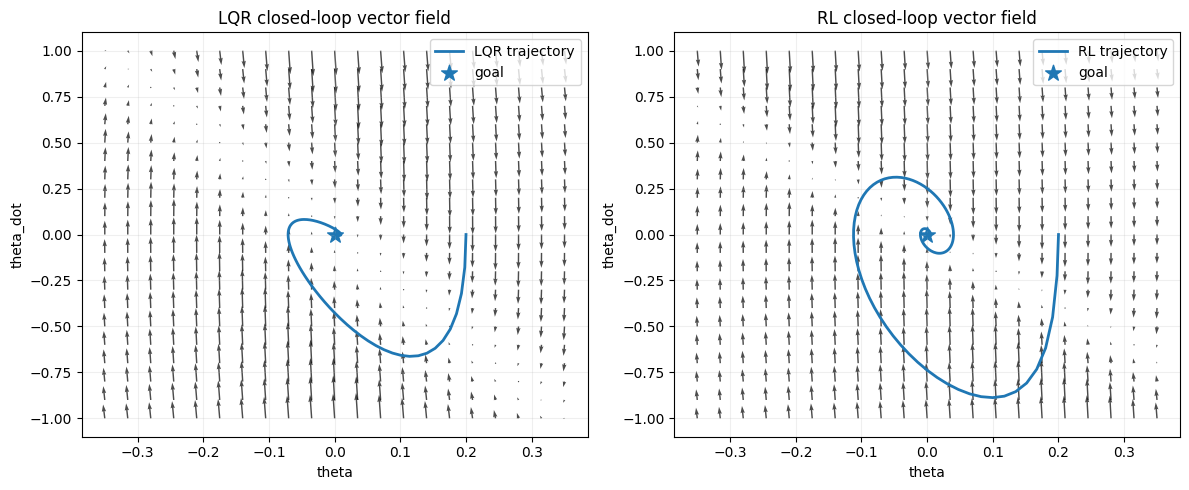

In [6]:
from rl_tmp.cartpole_rl import (
    rollout_cartpole_policy,
    train_cartpole_policy_search,
)

goal_state = np.array(
    [0.0, 0.0, 0.0, 0.0],
    dtype=np.float64,
)

rl_result = train_cartpole_policy_search(
    initial_state=initial_state,
    goal_state=goal_state,
    config=config,
    t_final=t_final,
    dt=dt,
    iterations=30,
    population_size=512,
    seed=0,
    device=device,
)

(
    rollout_times,
    controlled_states,
    actions,
    final_goal_distance,
    reached_goal,
) = rollout_cartpole_policy(
    policy=rl_result.policy,
    initial_state=initial_state,
    goal_state=goal_state,
    config=config,
    t_final=t_final,
    dt=dt,
    goal_tolerance=0.1,
    device=device,
)

initial_goal_distance = np.linalg.norm(
    initial_state - goal_state
)

print(
    "initial state distance to goal:",
    initial_goal_distance,
)
print(
    "elite mean goal distance:",
    rl_result.history["elite_mean_goal_distance"][0],
    "->",
    rl_result.history["elite_mean_goal_distance"][-1],
)
print(
    "final state distance to goal:",
    final_goal_distance,
)
print("reached goal:", reached_goal)
print("final state:", controlled_states[-1].numpy())

plot_training(
    rl_result.history,
    title="Cart-Pole CEM policy search",
)

plot_state_trajectories(
    times=rollout_times,
    reference=lqr_trajectory[:len(controlled_states)],
    prediction=controlled_states.numpy(),
    labels=("LQR + DOP853", "RL policy"),
    title="Goal-reaching control: LQR vs RL",
)

plot_cartpole_rl_closed_loop_fields(
    policy=rl_result.policy,
    config=config,
    lqr_gain=lqr_gain,
    lqr_trajectory=lqr_trajectory,
    rl_trajectory=controlled_states,
    goal_state=goal_state,
    device=device,
)
